_Neural Data Science_

Lecturer: Dr. Jan Lause, Prof. Dr. Philipp Berens

Tutors: Jonas Beck, Fabio Seel, Julius Würzler

Summer term 2025

Student names: <span style='background: yellow'>*FILL IN YOUR NAMES HERE* </span>

LLM Disclaimer: <span style='background: yellow'>*Did you use an LLM to solve this exercise? If yes, which one and where did you use it? [Copilot, Claude, ChatGPT, etc.]* </span>

# Coding Lab 1

## Introduction

In this coding lab you get to implement a pipeline for spike detection and feature extraction, as presented in the lecture:
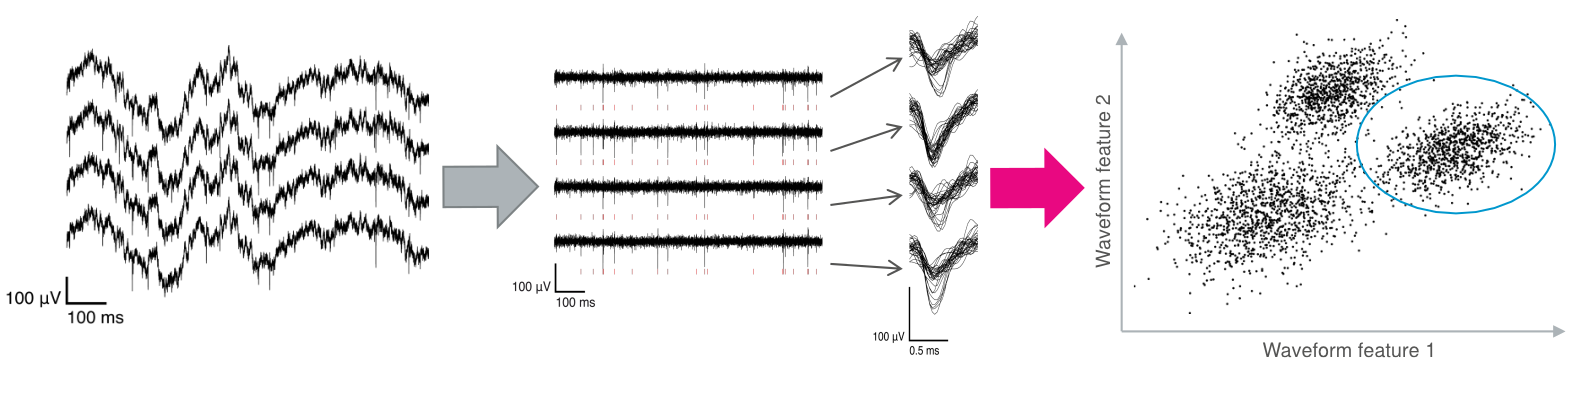

This will later be used for spike sorting (identifying which spike / waveform in the signal was caused by which neuron).

The data used in this notebook was recorded at 30kHz with a tetrode and thus contains the voltage traces of the 4 channels in μV.

_(for more information on the data acquisition, you can have a look at [Ecker et al 2014](https://doi.org/10.1016/j.neuron.2014.02.006), in particular the supplementary material. A similar pipeline is also used in [Ecker et al 2010](https://doi.org/10.1126/science.1179867). Note however that we only use a small portion of the data in this notebook and most of the experiment setup is not relevant here!)_

## Setup
- __Data__: Download the data file ```nds_cl_1.csv``` from ILIAS and save it in a subfolder ```../data/```.
- __Dependencies__: You don't have to use the exact versions of all the dependencies in this notebook, as long as they are new enough. But if you run "Run All" in Jupyter and the boilerplate code breaks, you probably need to upgrade them.


Recommended folder structure:

```
.
├── data/
│   └── nds_cl_1.csv
├── notebooks
│   └── CodingLab1.ipynb
├── matplotlib_style.txt
└── requirements.txt
```

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import butter, filtfilt
from scipy.signal import find_peaks
from sklearn.decomposition import PCA
from __future__ import annotations  # for Python 3.8 and below

# black is a code formatter (see https://github.com/psf/black).
# It will automatically format the code you write in the cells imposing consistent Python style.
%load_ext jupyter_black

%load_ext watermark
%watermark --time --date --timezone --updated --python --iversions --watermark -p sklearn

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black
The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Last updated: 2025-04-23 16:39:54W. Europe Daylight Time

Python implementation: CPython
Python version       : 3.11.11
IPython version      : 9.1.0

sklearn: 1.6.1

sklearn   : 1.6.1
scipy     : 1.15.2
numpy     : 2.2.4
pandas    : 2.2.3
matplotlib: 3.10.1

Watermark: 2.5.0



In [24]:
# matplotlib style file
# Template for style file: https://matplotlib.org/stable/tutorials/introductory/customizing.html#customizing-with-style-sheets
plt.style.use("../matplotlib_style.txt")

## Load data

In [25]:
fs = 30000.0  # sampling rate of the signal in Hz
dt = 1 / fs
cols = ["Ch1", "Ch2", "Ch3", "Ch4"]
x = pd.read_csv("../data/nds_cl_1.csv", header=0, names=cols)

In [26]:
x.describe()

,Ch1,Ch2,Ch3,Ch4
count,1.920000e+07,1.920000e+07,1.920000e+07,1.920000e+07
mean,3.600331e+00,-8.850918e-01,2.864284e-01,2.210982e+00
std,5.824474e+02,6.014818e+02,6.464363e+02,6.126105e+02
min,-3.607000e+03,-3.739000e+03,-3.871000e+03,-3.750000e+03
25%,-3.460000e+02,-3.610000e+02,-3.950000e+02,-3.640000e+02
50%,1.200000e+01,8.000000e+00,-1.000000e+00,1.000000e+01
75%,3.650000e+02,3.720000e+02,4.010000e+02,3.810000e+02
max,2.873000e+03,3.004000e+03,3.099000e+03,3.017000e+03


## Task 1: Filter Signal

In order to detect action potentials, the first step is to filter out low frequency fluctuations (LFP) and high frequency noise. Determine appropriate filter settings and implement the filtering in the function ```filter_signal()```. A typical choice for this task would be a <mark>butterworth filter</mark>.

Plot a segment of the raw signal and the filtered signal for all four channels with matching y-axis. The segment you choose should contain spikes. When you apply the function also test different filter settings.

*Grading: 3 pts*


In [27]:
## Current Best Practice
def filter_signal(
    x: pd.DataFrame, fs: float, low: float, high: float, order: int = 3
) -> pd.DataFrame:
    """Filter raw signal x.

    Parameters
    ----------

    x: pd.DataFrame, (n_samples, n_channels)
        Each column in x is one recording channel.

    fs: float
        Sampling frequency.

    low, high: float, float
        Passband in Hz for the butterworth filter.

    order: int
        The order of the Butterworth filter. Default is 3, but you should try
        changing this and see how it affects the results.


    Returns
    -------

    y: pd.DataFrame, (n_samples, n_channels)
        The filtered x. The filter delay is compensated in the output y.


    Notes
    ----

    1. Try exploring different filters and filter settings. More info:
    https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html

    2. The output signal should be phase-shift compensated. More info:
    https://dsp.stackexchange.com/a/19086

    """
    # -----------------------------------------------------------------
    # implement a suitable filter and apply it to the input data (1pt)
    # -----------------------------------------------------------------

    b, a = butter(order, [low, high], btype="band", fs=fs)
    y_vals = filtfilt(b, a, x.values, axis=0)
    return pd.DataFrame(y_vals, index=x.index, columns=x.columns)

In [28]:
xf = filter_signal(x, fs, low=300, high=6000, order=4)

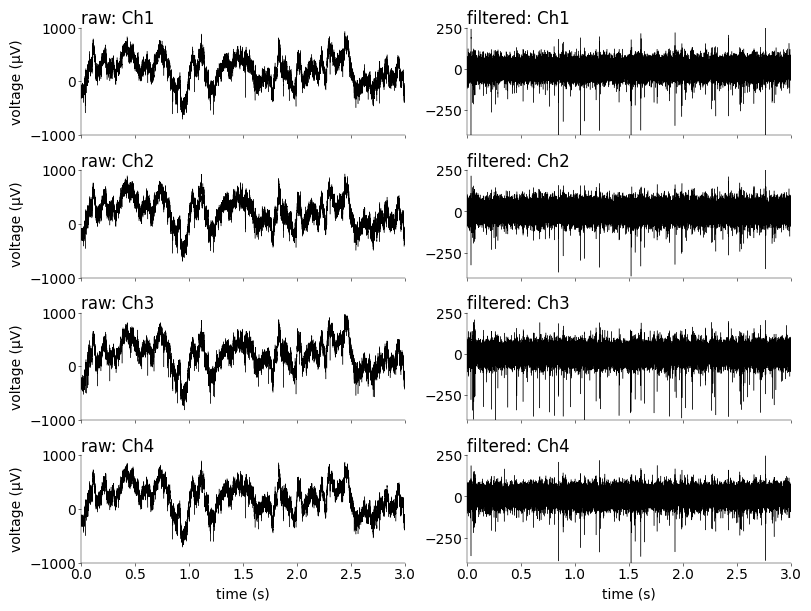

In [38]:
mosaic = [
    ["raw: Ch1", "filtered: Ch1"],
    ["raw: Ch2", "filtered: Ch2"],
    ["raw: Ch3", "filtered: Ch3"],
    ["raw: Ch4", "filtered: Ch4"],
]
fig, ax = plt.subplot_mosaic(
    mosaic=mosaic, figsize=(8, 6), layout="constrained", dpi=100
)

# ------------------------------------------------------------------------------------
# Plot raw and filtered signals for all 4 channels and answer the questions (1+1 pts)
# ------------------------------------------------------------------------------------

T = 100000
t = np.arange(0, T) * dt

for i, (raw, filtered) in enumerate(mosaic):
    ch = raw.split(": ")[1]
    ax[raw].plot(t, x[ch].values[:T], color="black", lw=0.3)
    ax[filtered].plot(t, xf[ch].values[:T], color="black", lw=0.3)

    ax[raw].set_xlim((0, 3))
    ax[raw].set_ylim((-1000, 1000))

    ax[filtered].set_xlim((0, 3))
    ax[filtered].set_ylim((-400, 250))

    # Add labels and title
    ax[raw].set_ylabel("voltage (μV)")
    ax[raw].set_title(raw, loc="left")
    ax[filtered].set_title(filtered, loc="left")
    if i != 3:
        ax[raw].set_xticklabels([])
        ax[filtered].set_xticklabels([])
    else:
        ax[raw].set_xlabel("time (s)")
        ax[filtered].set_xlabel("time (s)")

### Questions

**1) Explain your implementation: Which filter and parameters did you choose and why?**

We used a Butterworth band‑pass filter of order 4, with a low‑cutoff of 300 Hz and a high‑cutoff of 6000 Hz. 

Butterworth filters have a maximally flat passband, so they don’t introduce ripples in the frequency band of interest. Using filtfilt applies the filter forward and backward to cancel phase shifts.

We picked 300 Hz as our low frequency cutoff because most action potential energy lies above a few hundred hertz, which effectively removes slow LFPs. We chose 6 kHz as our high frequency cutoff to attenuate high‑frequency electronic or thermal noise.

An order of 4 gives a steeper roll‑off without any discernable negative side-effects on the signal.

**2) Which parameters of the function can be adjusted, which are determined by the experiment setup? What is the effect of the adjustable parameters?**

Determined by experiment:

- Sampling rate (30 KHz).
- Number of channels

Adjustable parameters

- Low‑cutoff frequency: raising it removes more LFPs but risks attenuating the slower components of the spike.
- High‑cutoff frequency: lowering it suppresses more high‑frequency noise but can also remove some spiking information if lowered too much.
- Filter order: higher order gives a steeper transition band but it and can also lead to numerical instability or implementation difficulties if increased too high.

Changing these lets you trade off between how cleanly you isolate spikes versus preserving their true waveform shape and avoiding artifactual distortions.

**3) How does the filtered signal look compared to the original? Why is this helpful as preprocessing in our spike detection pipeline?**

After filtering:

- Baseline drift and slow LFPs are removed, so the signal oscillates tightly around zero. This removes slow fluctuations that could shift our detection threshold
- High‑frequency noise is substantially attenuated above ~6 kHz which reduces possible false positives

therefore spikes stand out more clearly 

## Task 2: Detect action potentials

Action potentials are usually detected by finding large-amplitude deflections in the continuous signal. A good choice of threshold for detecting spikes is important. If it is too low, you will detect too many low amplitude events (noise); if it is too high, you run the risk of missing good spikes. Implement an automatic procedure to obtain a reasonable threshold and detect the times when spikes occurred in the function ```detect_spikes()```.

Plot a segment of the filtered signal for all four channels with matching y-axis and indicate the time points where you detected spikes, also **plot the threshold**.

*Grading: 4 pts*

In [30]:
def detect_spikes(
    x: np.ndarray, fs: float, N: int = 5, lockout: float = 1.0
) -> tuple[np.ndarray, np.ndarray, np.float64]:
    """Detect spikes in the signal x and compute a threshold.

    Parameters
    ----------

    x: np.array (n_samples, n_channels)
        The filtered signal from Task 1.

    fs: float
        the sampling rate (in Hz).

    N: int
        An arbitrary number with which you multiply with the standard deviation
        to set a threshold that controls your false positive rate. Default is 5
        but you should try changing it and see how it affects the results.

    lockout: float
        a window of 'refractory period', within which there's only one spike.
        Default is 1ms but you should also try changing it.


    Returns
    -------

    s: np.array, (n_spikes, )
        Spike location / index in the signal x.

    t: np.array, (n_spikes, )
        Spike time in ms. By convention the time of the zeroth sample is 0 ms.

    thrd: float
        Threshold = -N * sigma.


    Tips
    ----

    You can use scipy functions like find_peaks for the detection.
    Note: There are four channels in signal x.

    """

    # --------------------------------------------------------------
    # compute the robust s.d. and calculate the threshold (0.5 pts)
    # --------------------------------------------------------------
    sigma = np.median(np.abs(x - np.median(x))) / 0.6745
    thrd = -N * sigma

    # --------------------------
    # find all spikes (1.5 pts)
    # --------------------------
    lockout_samples = int((lockout / 1000.0) * fs)
    s, _ = find_peaks(
        np.max(-(x - np.median(x)), axis=1), height=-thrd, distance=lockout_samples
    )
    t = (s / fs) * 1000.0

    return s, t, thrd

In [31]:
s, t, thrd = detect_spikes(xf.values, fs)

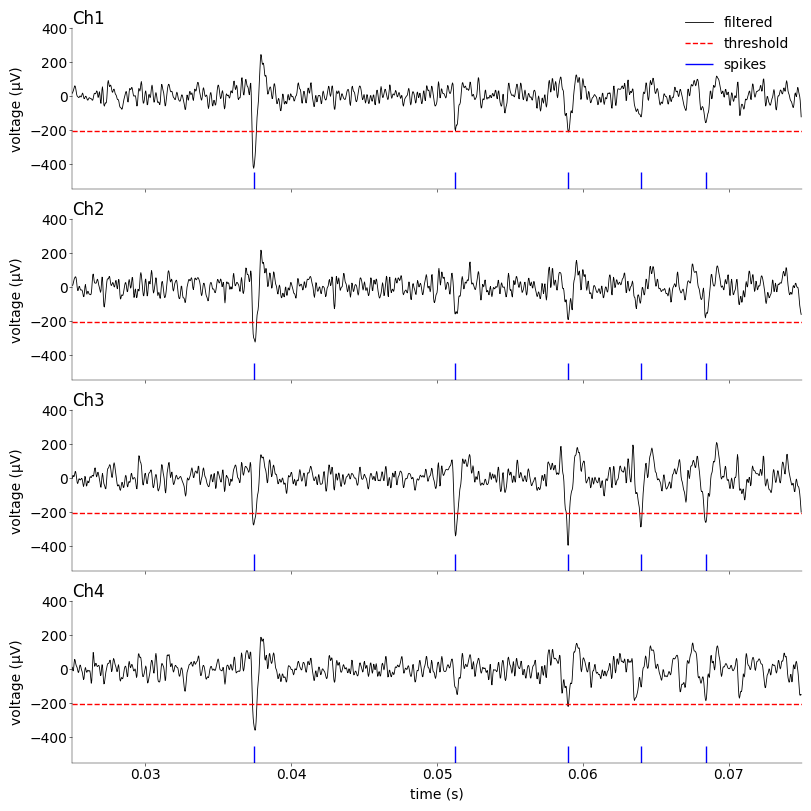

In [36]:
mosaic = [
    ["Ch1"],
    ["Ch2"],
    ["Ch3"],
    ["Ch4"],
]
fig, ax = plt.subplot_mosaic(
    mosaic=mosaic, figsize=(8, 8), layout="constrained", dpi=100
)

# ------------------------------------------------------------------------------
# plot signal, threshold and detected spikes and answer the questions (1+1 pts)
# ------------------------------------------------------------------------------

time = np.arange(len(xf)) / fs
start = 0.025
end = start + 0.05
idx_start, idx_end = int(start * fs), int(end * fs)

for i, col in enumerate(cols):

    ax[col].plot(
        time[idx_start:idx_end],
        xf[col].values[idx_start:idx_end],
        label="filtered",
        color="black",
        lw=0.6,
    )
    ax[col].hlines(thrd, start, end, linestyles="--", color="red", label="threshold")

    window = (s >= idx_start) & (s <= idx_end)
    s_in = s[window]
    t_in = t[window] / 1000
    # ax[col].vlines(
    #     t_in, -300, 300, linestyles="--", color="blue", alpha=0.4, label="spikes"
    # )

    ax[col].eventplot(
        t_in, lineoffsets=-500, colors="blue", linelengths=100, label="spikes"
    )

    ax[col].set_ylim((-550, 400))
    ax[col].set_xlim((start, end))
    ax[col].set_ylabel("voltage (μV)")

    ax[col].set_title(col, loc="left")

    if col == "Ch1":
        ax[col].legend(loc="upper right", bbox_to_anchor=(1.0, 1.15))

    if col != "Ch4":
        ax[col].set_xticklabels([])
    else:
        ax[col].set_xlabel("time (s)")

### Questions

1) Are the detected time points well aligned with prominent extrema in the signal? Also compare your detections across channels.
    
    Yes, the detected time points are well aligned with prominent negative extrema (troughs) in at least one of the channels. This is expected, since spike detection is based on the maximum negative deflection across all four channels. However, not every detected spike corresponds to a strong deflection on all channels. Some spikes are clearly visible on one or two channels but appear much weaker or even absent on others. This is because the detection rule triggers when any channel exceeds the threshold, so a spike originating near one electrode may not be strongly represented on the others. As a result, spike detections are often well-aligned with the largest deflection on the "dominant" channel but may not coincide with prominent features on the others.

2) Take one feature of the spikes and explain how that can help us identifying the source neuron of a spike (only based on visual examination of the plot).

    One useful feature is the relative amplitude of the spike across channels. Since each electrode is closer to some neurons than others, a spike from a given neuron will appear strongest on the nearest channel and weaker on more distant ones. By examining which channel shows the largest deflection during a spike, we can infer the approximate location of the source neuron. For example, if a spike produces its largest negative trough on channel 2 and smaller signals on the others, it likely originated from a neuron closest to channel 2. This spatial pattern helps distinguish spikes from different neurons based on the differences between different channels in the tetrode.

## Task 3: Extract waveforms
For later spike sorting we need the waveforms of all detected spikes. Extract the waveforms segments (1 ms) on all four channels for each spike time (as a result each spike is represented by a 4x30 element matrix). Implement this procedure in the function ```extract_waveforms()```.

Plot (a) the first 100 spikes you detected and (b) the 100 largest spikes you detected.
Are there a lot of very small spikes (likely noise) among your detected spikes? If so your threshold may be too low. Can you see obvious artifacts, not looking like spikes at all?

*Grading: 3 pts*

In [52]:
def extract_waveforms(x: np.ndarray, s: np.ndarray) -> np.ndarray:
    """Extract spike waveforms at times s (given in samples)
    from the filtered signal `xf` using a fixed window around the
    times of the spikes.

    Parameters
    ----------

    x: np.array (n_samples, n_channels)
        The filtered signal.

    s: np.array, (n_spikes, )
        Spike time in samples.


    Return
    ------

    w: np.array, (n_spikes, length_window, n_channels)
        Waveforms. (You don't have to get the exact same
        shape as we noted here. It's just the shape of w
        that can be easily retrieved via broadcasting.)


    Notes
    -----

    More on Numpy Broadcasting
    https://jakevdp.github.io/PythonDataScienceHandbook/02.05-computation-on-arrays-broadcasting.html

    """
    # -------------------------------
    # extract spike waveforms (1 pt)
    # -------------------------------

    window_size = int(0.001 * fs)  # 1ms
    third_w = window_size // 3
    two_thirds_w = window_size - third_w

    n_samples, n_channels = x.shape
    valid = (third_w <= s) & (s + two_thirds_w <= n_samples)
    s_valid = s[valid]

    w = np.zeros((s_valid.size, window_size, n_channels))

    offsets = np.arange(-third_w, two_thirds_w)
    spike_windows = s_valid[:, np.newaxis] + offsets
    w = x[spike_windows, :]

    return w

In [53]:
w = extract_waveforms(xf.values, s)

window_size = w.shape[1]
third_w = window_size // 3
t_wave = (np.arange(window_size) - third_w) / fs * 1000  # ms

amps = np.max(np.abs(w), axis=(1, 2))
largest_idxs = np.argsort(amps)[-100:]

Plot first 100 spike waveforms

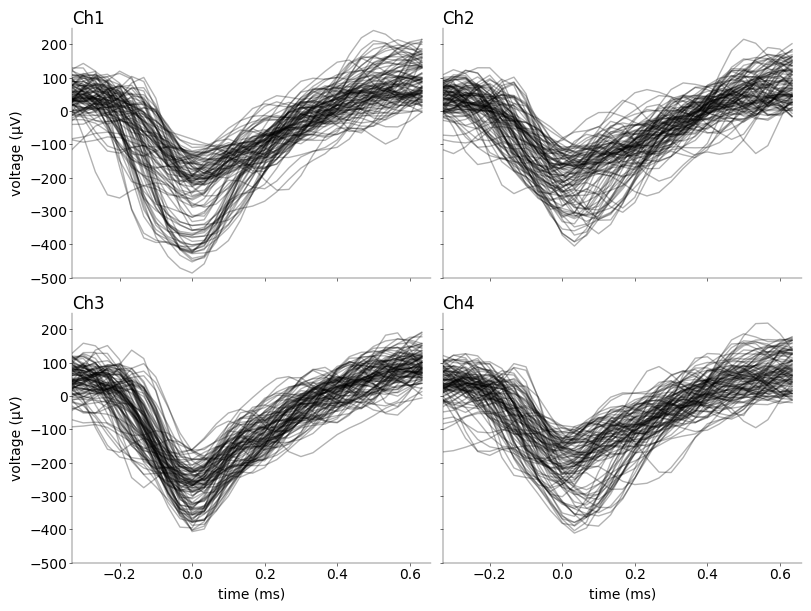

In [54]:
# ---------------------------------------------------------------------
# plot first and largest 100 spikes and answer the questions (1+1 pts)
# ---------------------------------------------------------------------

# first 100 spikes

mosaic = [
    ["Ch1", "Ch2"],
    ["Ch3", "Ch4"],
]
fig, ax = plt.subplot_mosaic(
    mosaic=mosaic, figsize=(8, 6), layout="constrained", dpi=100
)

# cols = ["Ch1", "Ch2", "Ch3", "Ch4"]
for i, col in enumerate(cols):

    for spike_id in range(min(100, w.shape[0])):
        ax[col].plot(t_wave, w[spike_id, :, i], color="black", alpha=0.3)

    # labeling etc
    ax[col].set_ylim((-500, 250))
    ax[col].set_xlim((-0.33, 0.66))
    ax[col].set_title(col, loc="left")
    if col == "Ch3" or col == "Ch4":
        ax[col].set_xlabel("time (ms)")
    else:
        ax[col].set_xticklabels([])
    if col == "Ch1" or col == "Ch3":
        ax[col].set_ylabel("voltage (μV)")
    else:
        ax[col].set_yticklabels([])

Plot largest 100 spike waveforms

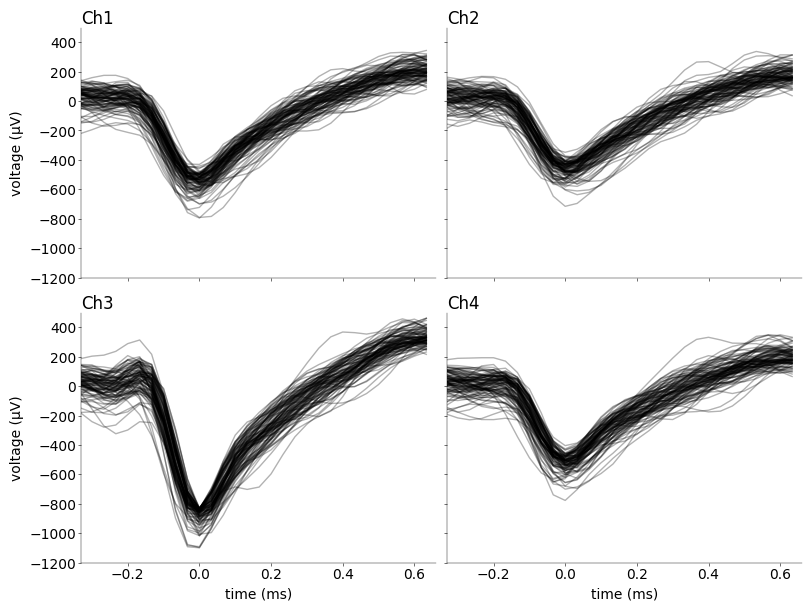

In [48]:
# largest 100 spikes

fig, ax = plt.subplot_mosaic(
    mosaic=mosaic, figsize=(8, 6), layout="constrained", dpi=100
)

for i, col in enumerate(cols):

    for spike_id in largest_idxs:
        ax[col].plot(t_wave, w[spike_id, :, i], color="black", alpha=0.3)

    # labeling etc
    ax[col].set_ylim((-1200, 500))
    ax[col].set_xlim((-0.33, 0.66))
    ax[col].set_title(col, loc="left")
    if col == "Ch3" or col == "Ch4":
        ax[col].set_xlabel("time (ms)")
    else:
        ax[col].set_xticklabels([])
    if col == "Ch1" or col == "Ch3":
        ax[col].set_ylabel("voltage (μV)")
    else:
        ax[col].set_yticklabels([])

### Questions

1) Describe the shape of the spikes.

    The spikes typically show a fast, large negative deflection, followed by a slower return toward baseline. The width of the trough is around 0.4 ms, spanning approximately −0.2 ms to +0.2 ms relative to the peak. After the negative deflection, we see a repolarizing phase of the neuron as a positive deflection above the baseline. For example, channel 3 in the largest 100 spikes plot clearly shows this. We don't see the neuron go back to baseline after repolarization because of the limited (1ms) window size.

   For the 100 largest spike, our interpretation of "largest" was the maximum absolute difference between the peak to the baseline. Among the 100 largest spikes, Channel 3 consistently shows the highest amplitude which suggests that the neuron generating these spikes is located closer to Channel 3, since spike amplitude decreases with distance from the source neuron.

3) Do the waveforms tend to be similar? If spikes have a similar waveform, what could that mean - and what does it mean if the waveforms look different?

    Yes, many of the waveforms appear quite similar in shape and amplitude, which suggests that they likely originate from the same neuron. Consistent waveforms across spikes and channels typically indicate that the signal comes from a single, nearby neuron. In contrast, differences in waveform shape may indicate the presence of multiple neurons firing, each with a distinct spatial footprint and spike timing. Variability can also result from noise, artifacts, or threshold settings that are too low, which may allow non-spike events to be falsely detected.

## Task 4: Extract features using PCA
Compute the first three PCA features on each channel separately in ```extract_features()```. You can use a available PCA implementation or implement it yourself. After that, each spike is represented by a 12 element vector. Compute the fraction of variance captured by these three PCs. Also return the obtained parameters of the PCA

For one channel, plot the mean and the first three principal axes as calculated by the PCA in the feature space. Interprete them in light of the plots in the previous tasks.

For all pairwise combinations of channels, plot the resulting features of the 1st PCs as scatter plots against each other. Do you see clusters visually?

*Grading: 6 pts*

## PCA
### Questions (1 pt)
1) If we input the data from each channel separately to a PCA, what are the feature dimension of the input?

    The PCA receives a matrix of shape (n_spikes, L), where L is the number of time samples in the waveform window (in our case 30 samples for a 1 ms window at 30 kHz). Each spike is treated as a single observation, and each time point is a feature (so the feature dimension is 30).

2) Therefore, what do the Principal Axes the PCA computes represent?

    The PCA principal axes are directions in this 30‑dimensional waveform space that capture the greatest variance across all spikes. Each axis is itself a length‑30 vector that depict a “typical waveform shape” that, when added to the mean, explains the greatest variance in our set of spikes. Projecting a spike onto the first principal axis measures how much that spike resembles the most dominant waveform variation in the data, the second axis captures the next most dominant shape difference, and so on.

3) Does it make sense to apply preprocessing steps, such as normalization? Have a look at the [scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html). What is applied by default?

    Yes, centering the data is essential however scaling to unit variance is not necessary in this context, since all features are in the same unit.

    By default, sklearn.decomposition.PCA automatically centers each feature but does not scale to unit variance.

In [17]:
"""Solution"""


def extract_features(w: np.ndarray) -> np.ndarray:
    """Extract features for spike sorting from the waveforms w.

    Do PCA on the waveforms of each channel separately,
    then concatenate the first three principal components
    of each channels into one numpy array (`b`).


    Parameter
    ---------

    w: np.ndarray, (n_spikes, length_window, n_channels)
        Waveforms from Task 3.


    Return
    ------

    b: np.ndarray, (n_spikes, n_feature)
        the transformed data
    means: np.ndarray, (n_channels, length_window)
        means per channel
    principal_components: np.ndarray, (n_channels, 3, length_window)
        the 'principal axes' obtained by the pca


    Notes
    -----

    You can use PCA from sklearn.

    More on PCA
    https://jakevdp.github.io/PythonDataScienceHandbook/05.09-principal-component-analysis.html

    """

    # ----------------------------------------------
    # obtain first 3 principle components (1.5 pts)
    # ----------------------------------------------

    n_spikes, win_len, n_ch = w.shape

    b = np.zeros((n_spikes, 3 * n_ch))
    means = np.zeros((n_ch, win_len))
    principal_components = np.zeros((n_ch, 3, win_len))
    explained_variance_ratio = np.zeros(n_ch)

    for ch in range(n_ch):
        data = w[:, :, ch]
        mean_ch = data.mean(axis=0)
        means[ch] = mean_ch
        data_centered = data - mean_ch

        pca = PCA(n_components=3)
        pcs_scores = pca.fit_transform(data_centered)
        pcs_axes = pca.components_
        var_ratio = pca.explained_variance_ratio_.sum()

        b[:, ch * 3 : (ch + 1) * 3] = pcs_scores
        principal_components[ch] = pcs_axes
        explained_variance_ratio[ch] = var_ratio

        # -----------------------------------------------------------------------------------------------------
        # Print the fraction of variance explained by the three components combined for each channel (0.5 pts)
        # -----------------------------------------------------------------------------------------------------
        print(f"Channel {ch+1}: first 3 PCs capture {var_ratio * 100:.2f}% of variance")

    return b, means, principal_components

In [18]:
b, means, principal_components = extract_features(w)

Channel 1: first 3 PCs capture 79.71% of variance
Channel 2: first 3 PCs capture 72.42% of variance
Channel 3: first 3 PCs capture 78.03% of variance
Channel 4: first 3 PCs capture 74.69% of variance


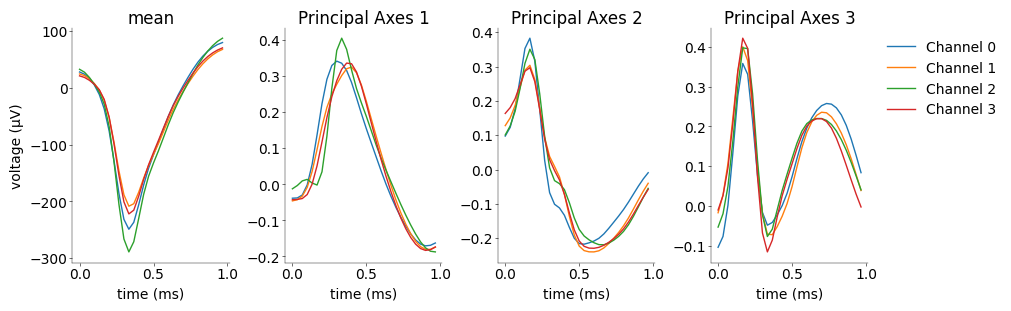

In [19]:
"""Solution"""

# ------------------------------------------------------------------------------------------------------------------
# Plot the mean of each channel and the three principal axes obtained by the PCA and answer the questions (1+1 pts)
# ------------------------------------------------------------------------------------------------------------------

length_window = means.shape[1]
t = np.arange(length_window) / fs * 1000  # convert to ms


mosaic = [
    ["mean", "Principal Axes 1", "Principal Axes 2", "Principal Axes 3"],
]
fig, ax = plt.subplot_mosaic(
    mosaic=mosaic, figsize=(10, 3), layout="constrained", dpi=100
)

for channel in range(4):
    ax["mean"].plot(t, means[channel])
    ax["Principal Axes 1"].plot(t, principal_components[channel, 0, :])
    ax["Principal Axes 2"].plot(t, principal_components[channel, 1, :])
    ax["Principal Axes 3"].plot(t, principal_components[channel, 2, :])

for channel in range(4):
    for i, mo in enumerate(np.ravel(mosaic)):

        ax[mo].set_xlabel("time (ms)")
        ax[mo].set_title(mo)

ax[mosaic[0][0]].set_ylabel("voltage (μV)")
ax[mosaic[0][-1]].legend(
    ["Channel " + str(i) for i in range(4)],
    bbox_to_anchor=(1.04, 1),
    loc="upper left",
)
plt.show()

### Questions

1) Compare the plot to the plots of the other tasks. What do you observe?

PC 1 closely resembles the average spike waveform (or its negative since eigenvectors are directionless, the sign doesn’t matter). In our overlay plots of the first 100 and the largest 100 spikes, we observed a consistent shape: a sharp negative trough followed by a positive rebound ending above baseline. PC 1 reflects this dominant structure because it captures the direction of greatest variance in the data, basically the “typical” spike.

In contrast, PC 2 and PC 3 could show additional “wiggles” that don’t resemble the average spike but instead capture systematic deviations from it. PC 2, for instance, often shows either a small positive deflection before or after the main spike, depending on the sign of the score. PC 3 tends to show positive fluctuations both before and after the spike. These components reflect subtler shape differences.

2) What does the mean look like? Does this match your expectations?

The mean waveform is exactly what we’d expect for a clean, well-filtered extracellular action potential: a rapid negative deflection followed by a positive rebound. This shape emerges clearly because averaging across many spikes suppresses noise and isolates the consistent structure shared by most spike waveforms. Its presence confirms that our detection and alignment procedure is working correctly.

3) Explain what it means if a spike has a high value in the first dimension. What is the effect of the other dimensions?

A high PC 1 score indicates a large-amplitude spike that closely matches the average shape. Since PC 1 is nearly identical to the mean waveform, spikes with large (negative in this case) PC 1 values are simply scaled versions of the typical spike. Conversely, a positive PC 1 value would partially cancel out the mean shape, corresponding to a lower-amplitude. Thus, PC 1 primarily captures overall spike amplitude and alignment with the average waveform.

PC 2 captures shape differences such as whether the waveform includes a small positive deflection just before or after the main trough. The sign and magnitude of the PC 2 score determine whether this “bump” leads or follows the main spike.

PC 3 captures more complex variations, such as symmetric fluctuations on both sides of the main trough.

In summary: while PC 1 reflects amplitude, PC 2 and PC 3 capture nuanced shape differences. Two spikes with similar PC 1 values might still differ in PC 2/3, enabling us to distinguish between neurons that fire with similar amplitudes but slightly different waveform shapes. That’s why multiple PCA dimensions are essential for effective spike sorting.

Text(0.5, 0.98, 'Pairwise 1st PCs')

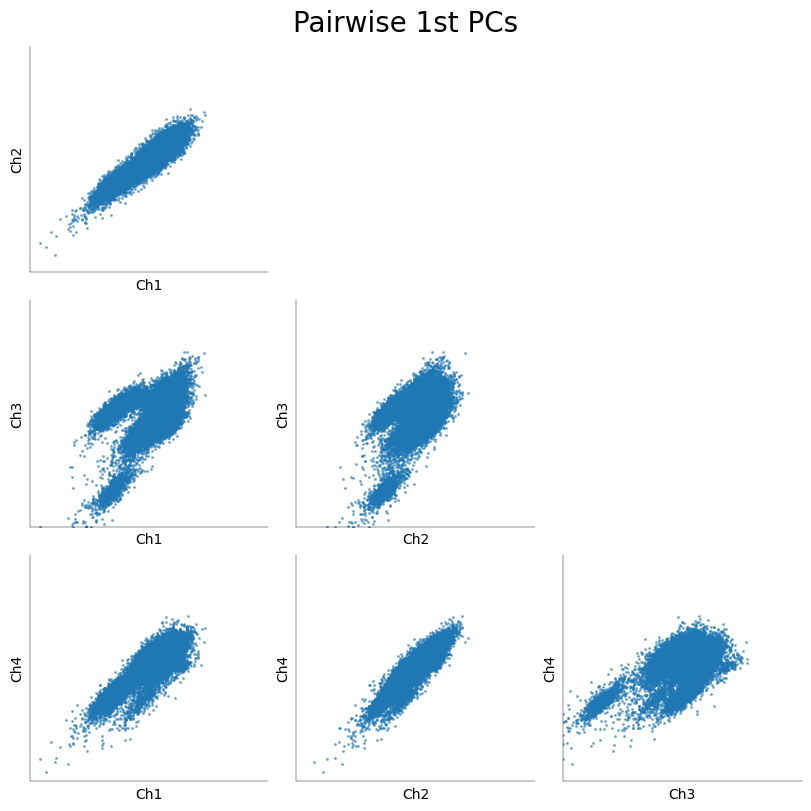

In [20]:
"""Solution"""

# ----------------------------------------------------------------------------------------------------------
# Create a scatterplot of the projections of the spikes for all pairwise combinations of the 1st PCs (1 pt)
# ----------------------------------------------------------------------------------------------------------

mosaic = [
    ["Ch2 vs Ch1", ".", "."],
    ["Ch3 vs Ch1", "Ch3 vs Ch2", "."],
    ["Ch4 vs Ch1", "Ch4 vs Ch2", "Ch4 vs Ch3"],
]
fig, ax = plt.subplot_mosaic(
    mosaic=mosaic, figsize=(8, 8), layout="constrained", dpi=100
)

# index of the 1st PC in `b`
i = {"Ch1": 0, "Ch2": 3, "Ch3": 6, "Ch4": 9}

for mo in np.ravel(mosaic):
    if mo == ".":
        continue
    y, x = mo.split(" vs ")

    x_idx = i[x]
    y_idx = i[y]

    ax[mo].scatter(b[:, x_idx], b[:, y_idx], s=5, alpha=0.5)

    ax[mo].set_xlabel(x)
    ax[mo].set_ylabel(y)
    ax[mo].set_xlim((-1500, 1500))
    ax[mo].set_ylim((-1500, 1500))
    ax[mo].set_xticks([])
    ax[mo].set_yticks([])

fig.suptitle("Pairwise 1st PCs", fontsize=20)

In [21]:
# save data for the next Coding Lab

# np.save("../data/nds_cl_1_features", b)
# np.save("../data/nds_cl_1_spiketimes_s", s)
# np.save("../data/nds_cl_1_spiketimes_t", t)
# np.save("../data/nds_cl_1_waveforms", w)